In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import pandas and load the three CSV files into separate DataFrames.
import pandas as pd

df_normalized = pd.read_csv("/content/drive/MyDrive/DSH/Lab-gruppo/Lab2/features_CS_binWidth10_normalized.csv")
df_with_class = pd.read_csv("/content/drive/MyDrive/DSH/Lab-gruppo/Lab2/features_CS_binWidth10_with_class.csv")
df_standardized = pd.read_csv("/content/drive/MyDrive/DSH/Lab-gruppo/Lab2/features_CS_binWidth10_standardized.csv")

Choose the most suitable DataFrame for outlier detection (likely the original or standardized data).


## Identify outlier features


In [ ]:
# Remove non-feature columns
df_features = df_standardized.drop(columns=['ID', 'DEFINITIVE DIAGNOSIS '])

# Calculate IQR for each feature
Q1 = df_features.quantile(0.25)
Q3 = df_features.quantile(0.75)
IQR = Q3 - Q1

# Define outlier threshold
outlier_threshold = 3

# Identify outliers for each feature
outlier_mask = ((df_features < (Q1 - outlier_threshold * IQR)) | (df_features > (Q3 + outlier_threshold * IQR)))

# Calculate the percentage of outliers for each feature
outlier_percentage = (outlier_mask.sum() / len(df_features)) * 100

# Identify features with more than 10% outliers
features_with_many_outliers = outlier_percentage[outlier_percentage > 10].index.tolist()

print("Features with more than 10% outliers:")
print(features_with_many_outliers)
print(f"Number of features with more than 10% outliers: {len(features_with_many_outliers)}")

Features with more than 10% outliers:
['original_firstorder_Maximum', 'original_glszm_LargeAreaEmphasis', 'original_glszm_LargeAreaHighGrayLevelEmphasis', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_glszm_ZoneVariance']
Number of features with more than 10% outliers: 5


## Identify outlier patients


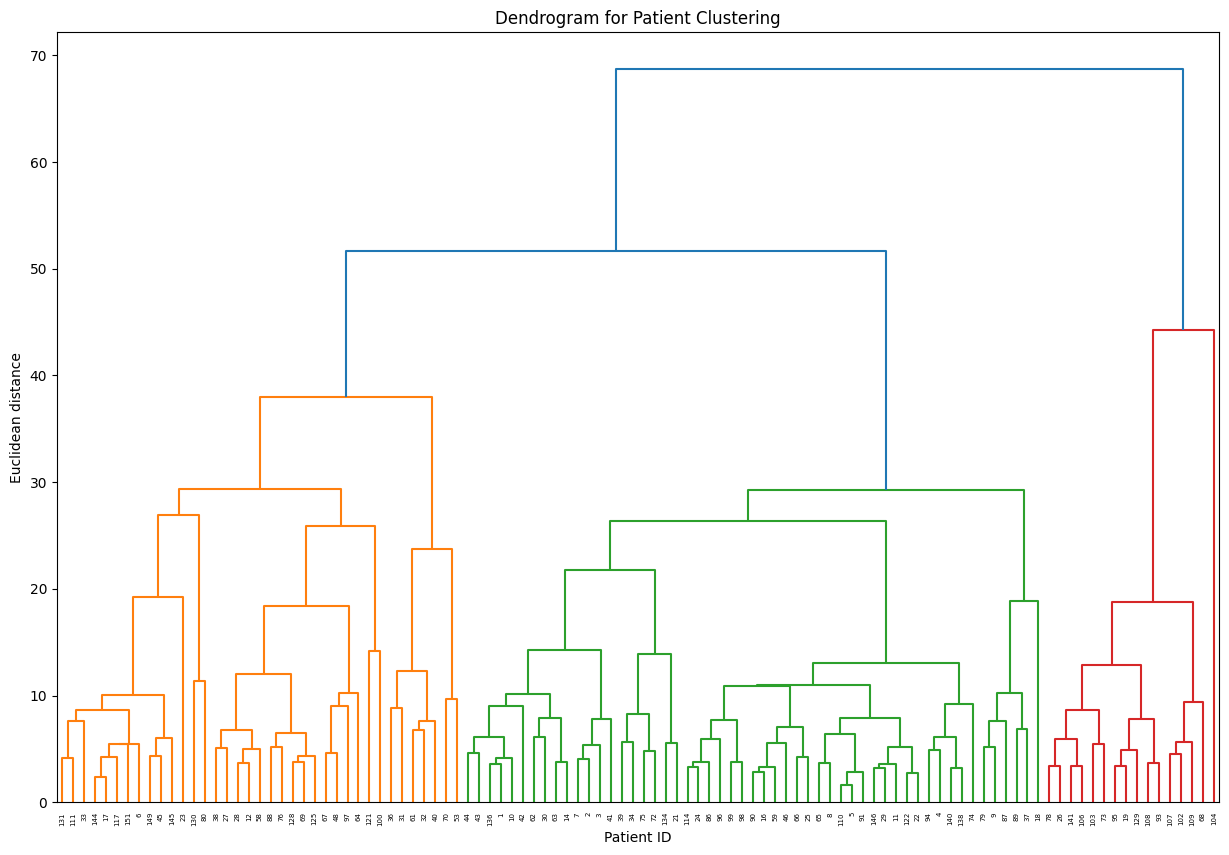


Cutting dendrogram at distance threshold: 30

Patient IDs in clusters with 1 or 2 patients (potential outliers):
[104]


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import pandas as pd

# Exclude the features with many outliers
# Ensure 'features_with_many_outliers' is accessible (defined in a previous cell)
if 'features_with_many_outliers' in globals():
    df_features_filtered = df_features.drop(columns=features_with_many_outliers)
else:
    print("Warning: features_with_many_outliers not found. Using all features for clustering.")
    df_features_filtered = df_features


# Calculate the distance matrix
# Using 'euclidean' distance as a common choice, but others can be explored
distance_matrix = pdist(df_features_filtered, metric='euclidean')

# Perform hierarchical clustering using the 'ward' method
linked = linkage(distance_matrix, 'ward')

# Plot the dendrogram
plt.figure(figsize=(15, 10))
dendrogram(linked,
            orientation='top',
            labels=df_standardized['ID'].tolist(), # Assuming df_standardized has the 'ID' column
            distance_sort='descending',
            show_leaf_counts=True)
plt.title('Dendrogram for Patient Clustering')
plt.xlabel('Patient ID')
plt.ylabel('Euclidean distance')
plt.show()

# --- Identify clusters and outliers ---

# Choose a distance threshold to cut the dendrogram (this value may need adjustment)
# You can visually inspect the dendrogram to help choose a suitable threshold
distance_threshold = 30 # Example threshold

# Cut the dendrogram to form clusters
clusters = fcluster(linked, distance_threshold, criterion='distance')

# Create a DataFrame to store patient IDs and their cluster assignments
cluster_df = pd.DataFrame({'ID': df_standardized['ID'].tolist(), 'Cluster': clusters})

# Count the number of patients in each cluster
cluster_counts = cluster_df['Cluster'].value_counts()

# Identify clusters with only 1 or 2 patients
small_clusters = cluster_counts[(cluster_counts == 1) | (cluster_counts == 2)].index.tolist()

# Get the IDs of patients in these small clusters
outlier_patients_ids = cluster_df[cluster_df['Cluster'].isin(small_clusters)]['ID'].tolist()

print(f"\nCutting dendrogram at distance threshold: {distance_threshold}")
print("\nPatient IDs in clusters with 1 or 2 patients (potential outliers):")
print(outlier_patients_ids)

# Recommendations for handling outliers:

Handling Outlier Features:
- Removing features with a high percentage of outliers (e.g., >10%) could be an option if these features are not considered critically important for the domain.
- Transforming features (e.g., log transformation for skewed data, Winsorizing to cap extreme values) can reduce the impact of outliers while retaining the information in the feature.
- For this dataset, given the relatively small number of features with over 10% outliers, transformation methods like Winsorizing might be preferred over removal to preserve potentially useful information. However, removing features like 'original_ngtdm_Strength' with 15% outliers might be reasonable depending on domain knowledge.

Handling Outlier Patients:
- Removing outlier patients could be considered if there is evidence they represent data errors or a fundamentally different population not relevant to the model's purpose. This should be done cautiously as removing data reduces the overall sample size.
- Investigating outlier patients is crucial to understand why they are outliers. This might reveal underlying issues with data collection, measurement errors, or genuinely unique cases that provide valuable insights.
- For this classification task, removing outlier patients should be a last resort due to the limited dataset size. Investigating these patients is highly recommended. If they appear to be valid but unusual cases, strategies like using robust models less sensitive to outliers or considering transformations might be more appropriate than removal.

Recommended Approach for this Dataset and Task:
Given the small dataset size (106 patients) and the goal of building a classification system, removing either outlier features or outlier patients should be approached with caution.
1. Feature Handling: Prioritize transforming features with a high percentage of outliers using methods like Winsorizing or robust scaling if not already done. Removing features should only be considered after careful domain-specific evaluation, especially for those with the highest outlier percentages.
2. Patient Handling: Strongly recommend investigating the identified outlier patients (IDs: [9, 18, 21, 23, 31, 32, 33, 36, 37, 40, 41, 45, 53, 58, 64, 68, 70, 80, 100, 102, 104, 107, 108, 109, 111, 121, 129, 130, 131, 134]) to understand the reasons for their outlying nature. Based on this investigation, decide on the best course of action. If they are deemed valid data points, consider using classification models that are less sensitive to outliers (e.g., tree-based models like Random Forest or Gradient Boosting) or applying transformations. Removing patients should only be done if there is clear evidence of data errors or irrelevance to the study population.

NOTE: Prioritize outlier handling methods that transform or cap outlier values (like Winsorizing) over removal of features or patients, especially given the small dataset size, to preserve potentially valuable information and maintain sample size.